[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [3]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.5


### Define the $Si_3N_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

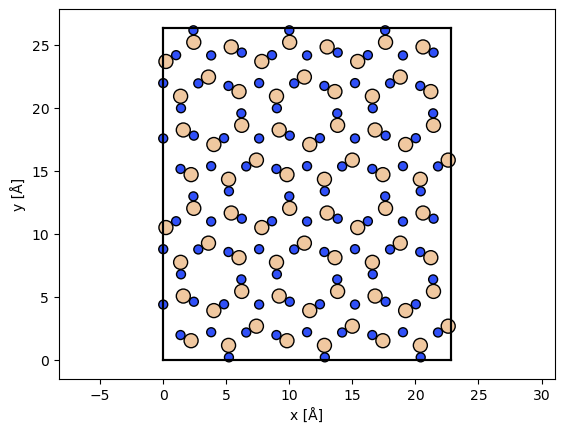

In [4]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
from abtem.atoms import orthogonalize_cell

structure_orthogonal = orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy', scale=0.5);

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

[########################################] | 100% Completed | 1.52 ss


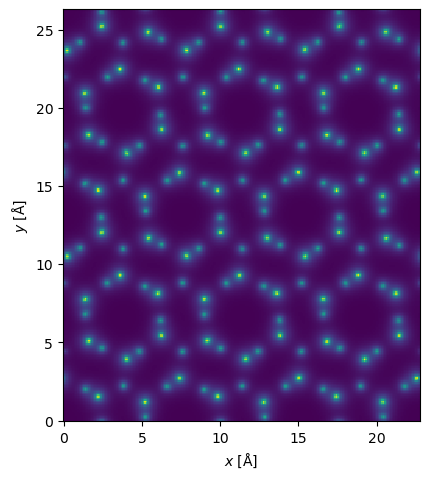

In [5]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

[########################################] | 100% Completed | 1.82 ss
[########################################] | 100% Completed | 1.39 ss


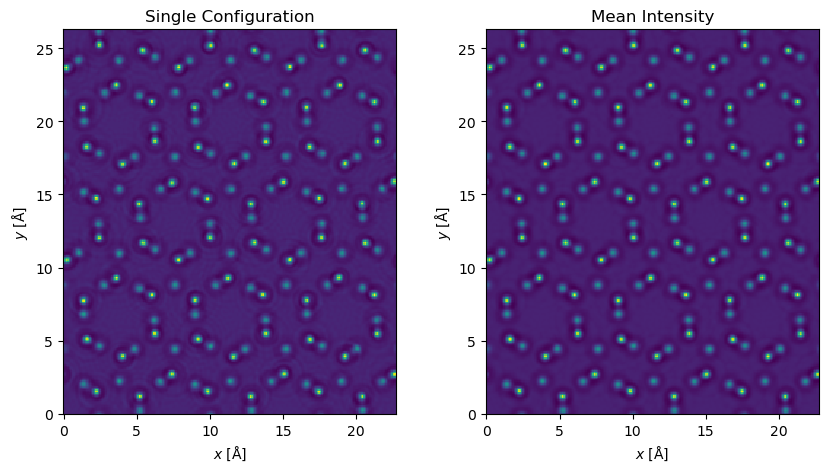

In [6]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
fig, ax = plt.subplots(1, 2, figsize=(10,5))
exit_waves.show(ax=ax[0], cmap='viridis')
ax[0].set_title('Single Configuration')
exit_waves.intensity().mean(0).show(ax=ax[1], cmap='viridis')
ax[1].set_title('Mean Intensity');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

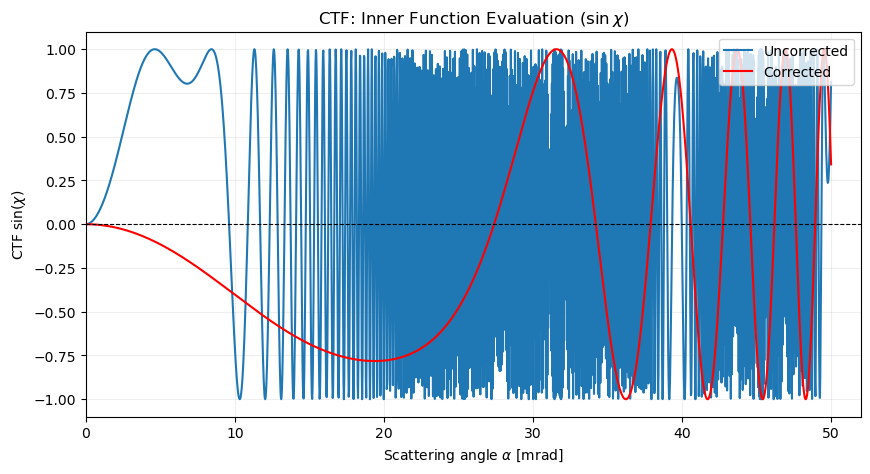

In [1]:
# TASK 3a: Define the UNCORRECTED CTF
# C10 = defocus (Δf) in Å  |  C30 = spherical aberration (Cs) in Å
# For a conventional 300 kV TEM: Cs ≈ 1.3 mm = 1.3e7 Å

import numpy as np
import matplotlib.pyplot as plt
import abtem

# 1) Define CTF parameters
params_uncorrected = {'C10': -600, 'C30': 1.3e7}
params_corrected   = {'C10': 30, 'C30': -8e4}

# 2) Create CTF objects
ctf_uncorrected = abtem.CTF(energy=300e3, aberration_coefficients=params_uncorrected)
ctf_corrected   = abtem.CTF(energy=300e3, aberration_coefficients=params_corrected)

prof_u = ctf_uncorrected.profiles()
prof_c = ctf_corrected.profiles()

# 2) Create the high-resolution angular grid (in radians)
alpha_max_rad = 0.050 
alpha_rad = np.linspace(0, alpha_max_rad, 2000)

# 3) Use the "Inner Function" to evaluate the complex phase
# This method returns the complex exponential exp(i*chi)
# We use [None] or a dummy phi because CTF is rotationally symmetric here
phi = np.zeros_like(alpha_rad)
complex_u = ctf_uncorrected._evaluate_from_angular_grid(alpha_rad, phi)
complex_c = ctf_corrected._evaluate_from_angular_grid(alpha_rad, phi)

# 4) Extract the Imaginary part (sin(chi))
y_u = complex_u.imag
y_c = complex_c.imag

# 5) Plotting
alpha_mrad = alpha_rad * 1000

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alpha_mrad, y_u, label='Uncorrected', lw=1.5)
ax.plot(alpha_mrad, y_c, label='Corrected', color='red', lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlim(0, 52)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(r'Scattering angle $\alpha$ [mrad]')
ax.set_ylabel(r'CTF $\sin(\chi)$')
ax.set_title("CTF: Inner Function Evaluation ($\sin\chi$)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)

plt.show()

[########################################] | 100% Completed | 1.28 ss
[########################################] | 100% Completed | 1.39 ss


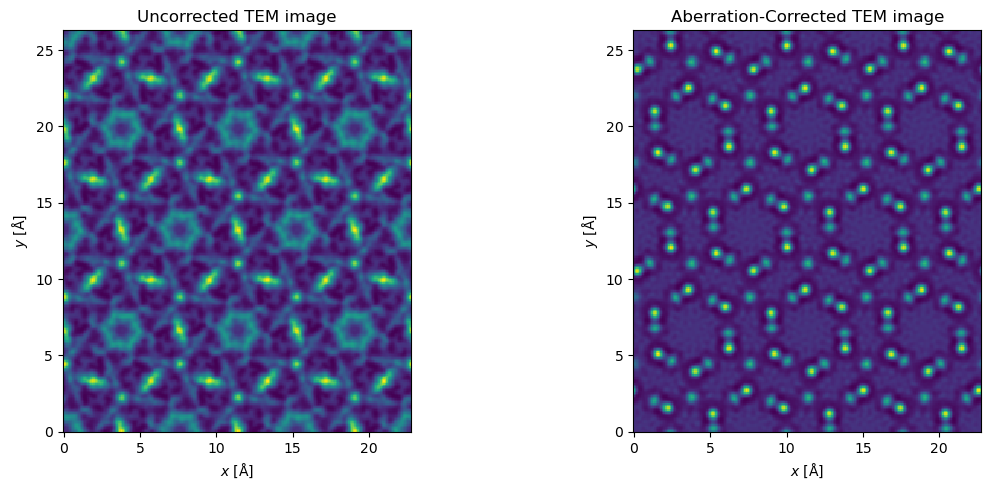

In [7]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='viridis', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='viridis', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

[########################################] | 100% Completed | 1.49 ss
[########################################] | 100% Completed | 1.62 ss


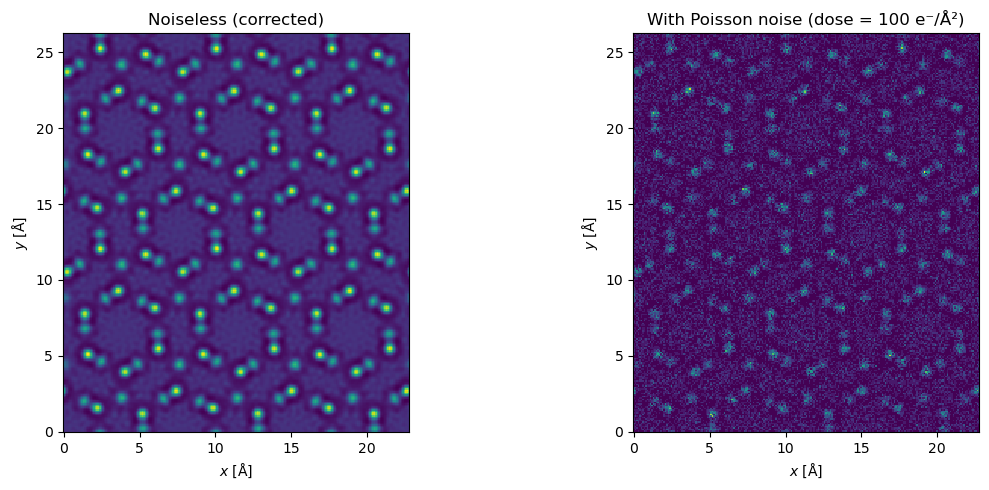

In [8]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# dose is in electrons per Å²; lower dose → more noise
dose = 100  # e⁻/Å²

# 1) Get the noiseless mean intensity image as before
noiseless_image = image_corrected.intensity().mean(0)

# 2) Apply Poisson noise using the built-in method
# In 1.0.5, the measurement object handles the dose scaling internally
noisy_image = noiseless_image.poisson_noise(dose)

# TASK 4: Plot the noiseless vs noisy images side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plotting noiseless
noiseless_image.show(cmap='viridis', ax=axes[0])
axes[0].set_title('Noiseless (corrected)')

# Plotting noisy
noisy_image.show(cmap='viridis', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')

plt.tight_layout()
plt.show()


# Export all figures

[########################################] | 100% Completed | 1.06 sms
[########################################] | 100% Completed | 1.38 ss
[########################################] | 100% Completed | 1.38 ss
[########################################] | 100% Completed | 1.29 ss
[########################################] | 100% Completed | 1.38 ss
[########################################] | 100% Completed | 1.40 ss
[########################################] | 100% Completed | 1.38 ss


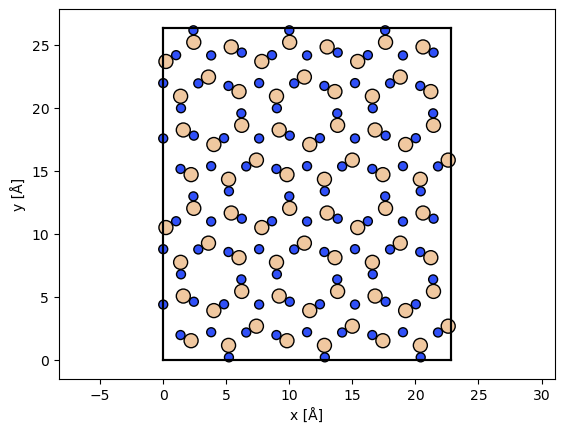

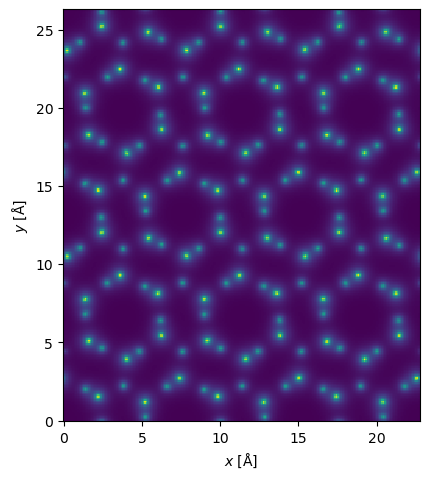

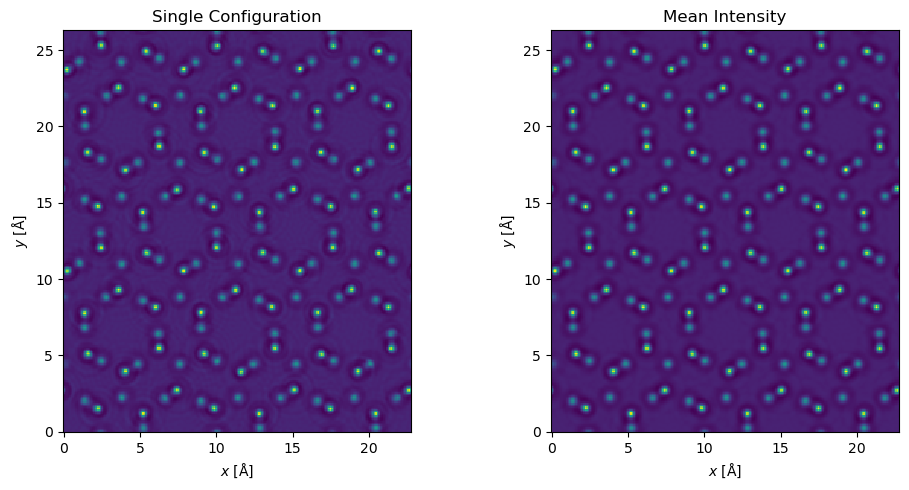

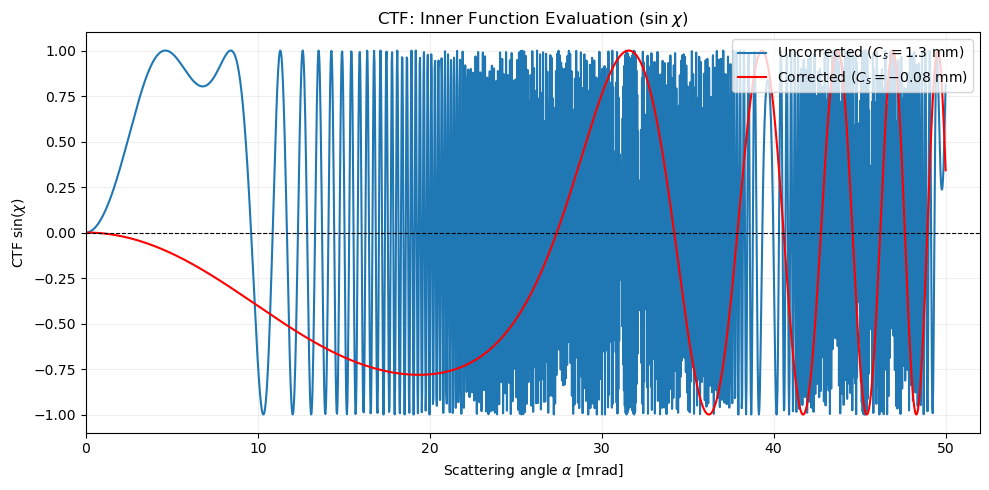

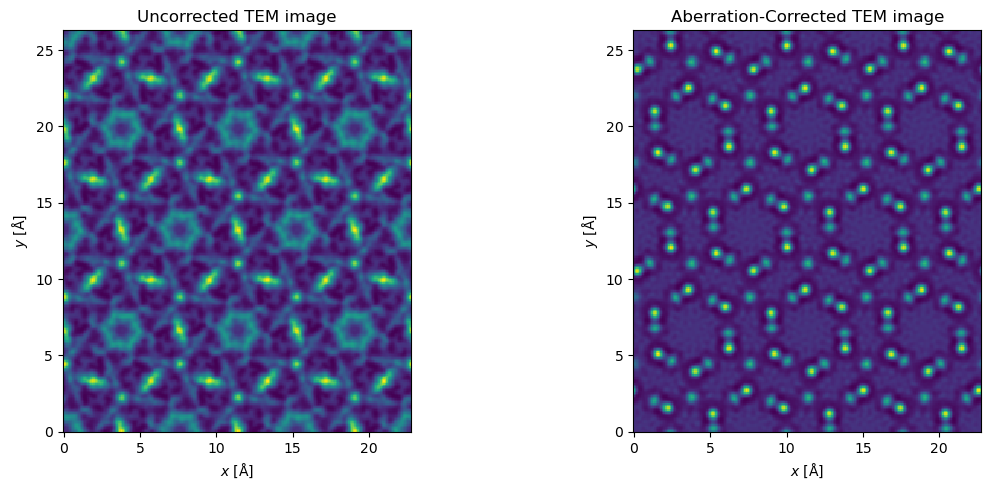

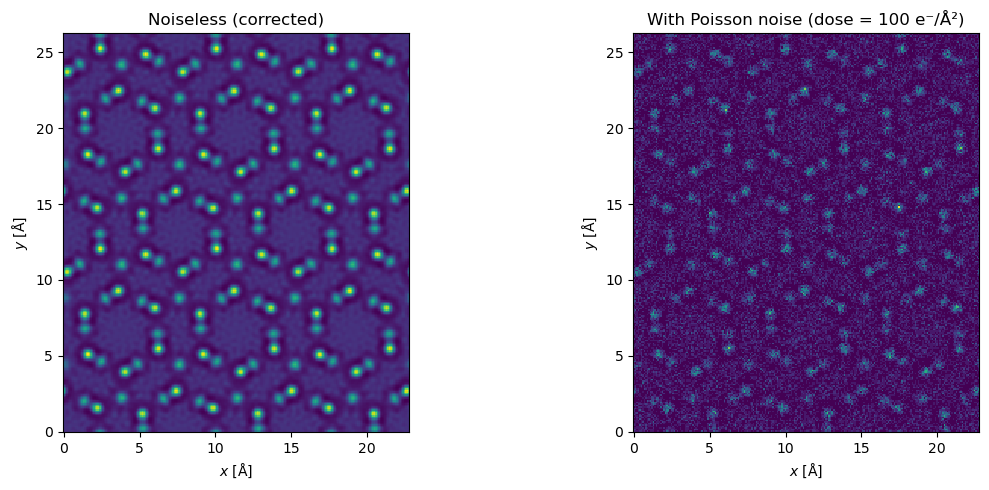

In [9]:
# Task 1

fig, ax = abtem.show_atoms(structure_orthogonal * (3, 2, 6), plane='xy', scale=0.5)
fig.savefig("orthogonal_structure.pdf", bbox_inches='tight')

potential.project().show(cmap='viridis')
plt.gcf().savefig("projected_potential.pdf", bbox_inches='tight')

# Task 2

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

exit_waves.show(ax=ax[0], cmap='viridis')
ax[0].set_title('Single Configuration')

exit_waves.intensity().mean(0).show(ax=ax[1], cmap='viridis')
ax[1].set_title('Mean Intensity')

fig.tight_layout()

fig.savefig("exit_wave_comparison.pdf", format='pdf', bbox_inches='tight')

# Task 3

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alpha_mrad, y_u, label='Uncorrected ($C_s=1.3$ mm)', lw=1.5)
ax.plot(alpha_mrad, y_c, label='Corrected ($C_s=-0.08$ mm)', color='red', lw=1.5)

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlim(0, 52)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(r'Scattering angle $\alpha$ [mrad]')
ax.set_ylabel(r'CTF $\sin(\chi)$')
ax.set_title("CTF: Inner Function Evaluation ($\sin\chi$)")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.2)
fig.tight_layout()

fig.savefig("CTF_comparison.pdf", format='pdf', dpi=300, bbox_inches='tight')

# Task 3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='viridis', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='viridis', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

fig.tight_layout()

fig.savefig("corrected_uncorrected_comparison.pdf", format='pdf', dpi=300, bbox_inches='tight')

# Task 4

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='viridis', ax=axes[0])
axes[0].set_title('Noiseless (corrected)')

noisy_image.show(cmap='viridis', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose} e⁻/Å²)')

fig.tight_layout()

fig.savefig("poisson_noise_comparison.pdf", format='pdf', dpi=300, bbox_inches='tight')

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?

- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?

- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?


- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?

The rapid oscillation of uncorrected CTF at high spatial frequencies shows transfer with positive/negative contrast and loss at points where CTF = 0. The aberration-corrected CTF remains consistent in phase transfer over a larger interval before oscillating.

- Why do we see sharper atomic columns in the aberration-corrected image?

The aberration-corrected CTF transfers high spatial frequencies in-phase with low frequencies, forming sharp, local peaks via constructive interference at the atomic columns.

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?

At zero defocus, the CTF is near-zero for a thin phase object and no amplitude contrast or phase shift is present. The phase shifts are converted to observable amplitude variations by defocus.

- What is the significance of the Scherzer defocus?

The Scherzer defocus is a specific underfocus which balances spherical aberration phase shift $C_s$ with defocus phase shift. The matching maximizes the bandwidth of stable CTF, where contrast resolution is optimized.

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?

Poisson noise simulates random/stochastic fluctuations of imaging with real electron doses, which obscure fine details in background noise. This effect is more pronounced for less responsive light nuclei or lower-dose imaging settings.

- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

Other factors include sample drift, mechanical vibrations, chromatic aberration, detector point spreads (e.g. MTF, DQE), amorphous surfaces, and non-unitary scattering from thicker regions.

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

Even for a 5nm sample, dynamical diffraction of multiple scattering events is significant. Compared to kinematic approximation of a single projected potential and single electron wave scattering event, the successive atomic layers of multislice method accurately predicts the exit waves in the multiple propagating and scattering stages.